# Lab 7 - Processamento Morfológico de Imagens
## **Disciplina:** MCZA018 - Processamento Digital de Imagens (2026.1)

### **Autores:**
* Eduardo Yukio Makita (11202020221)
* Gustavo Fernandes do Nascimento (11202021700)
* Igor Ladeia de Freitas (11201922180)
* Ryan Lucas da Silva (11202522362)

**Data de Realização:** 14 de Abril de 2026
**Data de Publicação:** 16 de Abril de 2026

## 3) Atividades Práticas Experimentais:

### a) Procedimentos e Análise: Imagens do Grupo

Nesta etapa, aplicamos as operações morfológicas básicas (Erosão, Dilatação, Abertura e Fechamento) nas imagens do grupo, variando o tamanho do elemento estruturante (kernel). 

**Análise dos Resultados:**
* **Binarização (Otsu):** Foi essencial usar o método de Otsu para separar perfeitamente as silhuetas do fundo, evitando a criação de ruídos brancos que prejudicariam a morfologia.
* **Erosão e Dilatação:** A erosão encolheu as formas (apagando detalhes com kernels maiores), enquanto a dilatação expandiu as silhuetas (fundindo os membros do grupo num único bloco ao usar o kernel 21x21).
* **Abertura e Fechamento:** A Abertura (erosão seguida de dilatação) limpou com sucesso pequenos ruídos isolados no fundo. O Fechamento (dilatação seguida de erosão) foi útil para tapar "buracos" escuros dentro das silhuetas causados por falhas na binarização.

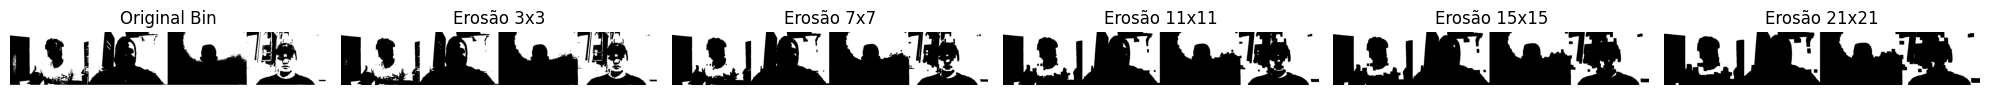

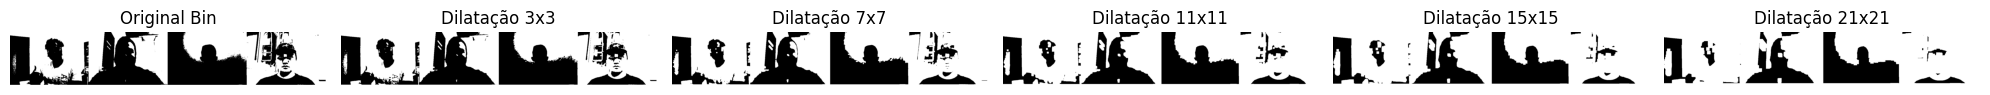

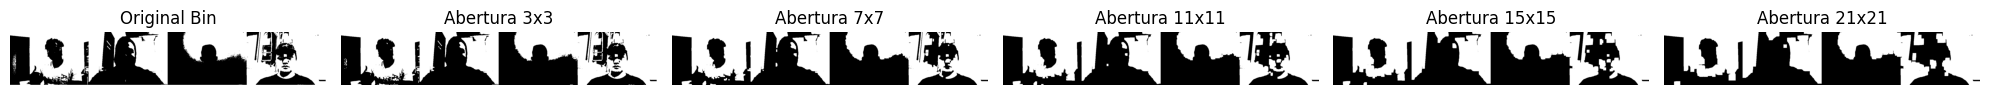

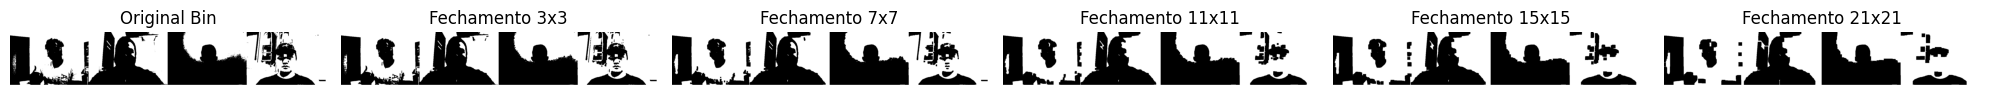

Todas as imagens foram geradas e salvas na pasta com sucesso!


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def exibir_multiplas(imagens, titulos, figsize=(20, 4)):
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    for ax, img, tit in zip(axes, imagens, titulos):
        ax.imshow(img, cmap='gray')
        ax.set_title(tit)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

nome_do_arquivo = 'imagem_grupo.png' 
img_bgr = cv2.imread(nome_do_arquivo)

if img_bgr is not None:
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    cv2.imwrite("0_original_binarizada.jpg", img_bin)

    tamanhos = [3, 7, 11, 15, 21]

    erosoes = [img_bin] + [cv2.erode(img_bin, np.ones((k, k), np.uint8), iterations=1) for k in tamanhos]
    exibir_multiplas(erosoes, ["Original Bin"] + [f"Erosão {k}x{k}" for k in tamanhos])
    for i, k in enumerate(tamanhos):
        cv2.imwrite(f"1_erosao_{k}x{k}.jpg", erosoes[i+1])

    dilatacoes = [img_bin] + [cv2.dilate(img_bin, np.ones((k, k), np.uint8), iterations=1) for k in tamanhos]
    exibir_multiplas(dilatacoes, ["Original Bin"] + [f"Dilatação {k}x{k}" for k in tamanhos])
    for i, k in enumerate(tamanhos):
        cv2.imwrite(f"2_dilatacao_{k}x{k}.jpg", dilatacoes[i+1])

    aberturas = [img_bin] + [cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, np.ones((k, k), np.uint8)) for k in tamanhos]
    exibir_multiplas(aberturas, ["Original Bin"] + [f"Abertura {k}x{k}" for k in tamanhos])
    for i, k in enumerate(tamanhos):
        cv2.imwrite(f"3_abertura_{k}x{k}.jpg", aberturas[i+1])

    fechamentos = [img_bin] + [cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, np.ones((k, k), np.uint8)) for k in tamanhos]
    exibir_multiplas(fechamentos, ["Original Bin"] + [f"Fechamento {k}x{k}" for k in tamanhos])
    for i, k in enumerate(tamanhos):
        cv2.imwrite(f"4_fechamento_{k}x{k}.jpg", fechamentos[i+1])
        
    print("Todas as imagens foram geradas e salvas na pasta com sucesso!")

else:
    print("Erro ao carregar a imagem.")

### b) Procedimentos e Análise: Programa Interativo (Webcam)

Desenvolvemos um script que captura a webcam e aplica o **Gradiente Morfológico** (`cv2.MORPH_GRADIENT`) em tempo real, permitindo alterar o tamanho do *kernel* via teclado.

**Análise dos Resultados:**
* **Extração de Fronteiras:** O gradiente calcula a diferença entre a dilatação e a erosão. O resultado prático é que as áreas sólidas são apagadas, restando apenas os contornos (bordas) das pessoas e objetos.
* **Influência do Kernel:** Ao pressionar 'w' e aumentar o kernel, a diferença entre a dilatação e a erosão aumenta, o que torna as bordas extraídas visivelmente mais grossas e borradas.
* **Artefatos (Ruídos):** O ajuste automático de brilho da webcam em ambientes com pouca luz gera pequenos ruídos no sensor. O algoritmo interpreta essas micro-variações de luz como "bordas", criando uma textura granulada ou rastros ao redor de quem está em movimento.

In [4]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

fourcc = cv2.VideoWriter_fourcc(*'XVID')

out = cv2.VideoWriter('gravacao_equipe_lab7.avi', fourcc, 20.0, (1280, 480))

k_size = 3

print("Pressione 'w' para aumentar o kernel, 's' para diminuir e 'q' para sair.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    frame = cv2.resize(frame, (640, 480)) # Padroniza o tamanho
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k_size, k_size))
    
    gradiente = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)
    
   
    gradiente_bgr = cv2.cvtColor(gradiente, cv2.COLOR_GRAY2BGR)
    
    cv2.putText(gradiente_bgr, f"Kernel: {k_size}x{k_size}", (20, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    resultado = cv2.hconcat([frame, gradiente_bgr])
    
    cv2.imshow('Original | Gradiente Morfologico', resultado)
    out.write(resultado) 
    
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('w'):
        k_size += 2 
    elif key == ord('s'):
        k_size = max(3, k_size - 2) 

cap.release()
out.release()
cv2.destroyAllWindows()

Pressione 'w' para aumentar o kernel, 's' para diminuir e 'q' para sair.


## 4. Exercícios Propostos
a) Aplicação no Trabalho Final: Identificação de Robôs em Campo

Contexto da Aplicação: Nosso projeto final consiste em um sistema de visão computacional para identificar a posição e orientação de robôs em um campo de futebol, utilizando marcadores geométricos coloridos sobre a carcaça dos robôs.

Objetivo do Procedimento Morfológico:

O ambiente do campo possui baixa luminosidade, o que gera bastante ruído na imagem capturada pela câmera. Quando aplicamos a segmentação de cor (por exemplo, buscando os marcadores azuis no espaço HSV) e binarizamos a imagem, obtemos uma máscara com dois problemas principais:

1. Ruído de Fundo (Falsos Positivos): Pequenos pontos brancos espalhados pelo campo causados por ruído do sensor da câmera em baixa luz ou reflexos. Utilizamos a Abertura (Opening) para apagar esses artefatos indesejados.

2. Fragmentação do Marcador (Falsos Negativos): O marcador do robô pode não ficar perfeitamente sólido na binarização, apresentando falhas internas. Aplicamos o Fechamento (Closing) sobre o resultado da abertura para "soldar" e preencher o marcador, garantindo que o cálculo do centro de massa do robô seja preciso.

Todas as imagens da Parte 4 foram salvas na pasta com sucesso!


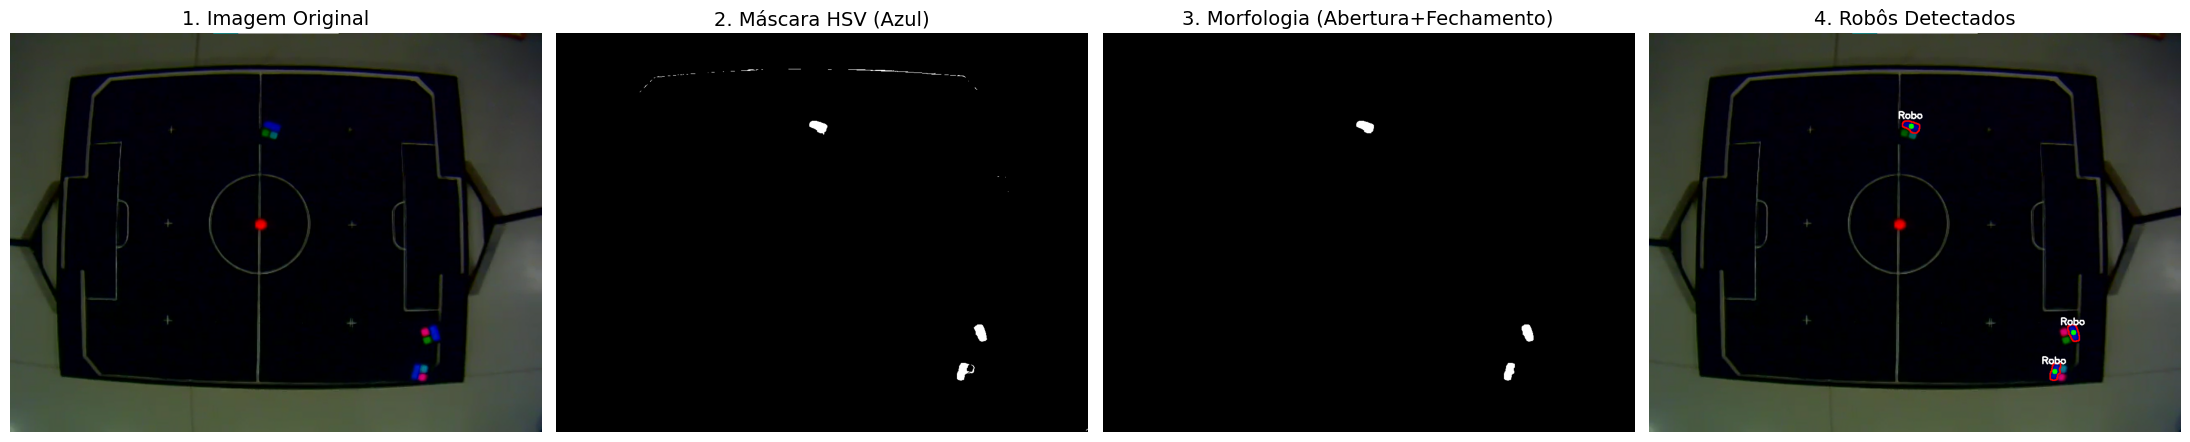

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def exibir_pipeline(imagens, titulos):
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=(22, 6))
    for ax, img, tit in zip(axes, imagens, titulos):
        if len(img.shape) == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap='gray')
        ax.set_title(tit, fontsize=14)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

img = cv2.imread('image_e9c507.png') 

if img is None:
    print("Erro: Imagem não encontrada. Verifique o nome do arquivo.")
else:
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([100, 150, 50])
    upper_blue = np.array([140, 255, 255])
    
    mask_crua = cv2.inRange(hsv, lower_blue, upper_blue)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    
    mask_aberta = cv2.morphologyEx(mask_crua, cv2.MORPH_OPEN, kernel)
    mask_limpa = cv2.morphologyEx(mask_aberta, cv2.MORPH_CLOSE, kernel)

    img_resultado = img.copy()
    
    contornos, _ = cv2.findContours(mask_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contornos:
        area = cv2.contourArea(cnt)
        if area > 30: 
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                
                cv2.drawContours(img_resultado, [cnt], -1, (0, 0, 255), 2)
                cv2.circle(img_resultado, (cX, cY), 5, (0, 255, 0), -1)
                cv2.putText(img_resultado, "Robo", (cX - 25, cY - 15), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.imwrite('4_etapa1_mask_hsv.jpg', mask_crua)
    cv2.imwrite('4_etapa2_mask_abertura.jpg', mask_aberta)
    cv2.imwrite('4_etapa3_mask_fechamento.jpg', mask_limpa)
    cv2.imwrite('4_etapa4_resultado_final.jpg', img_resultado)
    print("Todas as imagens da Parte 4 foram salvas na pasta com sucesso!")

    exibir_pipeline(
        [img, mask_crua, mask_limpa, img_resultado],
        ['1. Imagem Original', '2. Máscara HSV (Azul)', '3. Morfologia (Abertura+Fechamento)', '4. Robôs Detectados']
    )

## 5. Questões de Análise do Processamento Morfológico de imagens
### a) Erosão e Estrutura

Questão: Ao aplicar uma erosão em uma imagem binária com ruídos brancos (1 pixel) usando um kernel 3x3 de uns, o que acontece com esses ruídos?

Resposta: Os ruídos de 1 pixel desaparecerão completamente. O operador de erosão funciona como um filtro de mínimo local. Para que um pixel na imagem resultante seja branco (1), todos os pixels cobertos pelo kernel 3x3 na imagem original devem ser brancos. Como um ruído isolado de 1 pixel está cercado por pixels pretos (0), a condição nunca é satisfeita, resultando em 0 (preto) naquela posição.

### b) Dilatação e Conectividade
Questão: Qual o efeito de aplicar uma dilatação com kernel 3x3 em um texto com letras "quebradas"? Existe efeito colateral se o kernel for grande demais?

Resposta: A dilatação irá expandir as bordas dos caracteres brancos, preenchendo as lacunas e reconectando as partes fragmentadas da letra. Se o kernel for excessivamente grande (ex: 15x15 ou 21x21), o espessamento será tão intenso que o espaço entre letras e palavras desaparecerá, fundindo o texto em blocos brancos ilegíveis.

### c) Extração de Contornos (Gradiente)
Questão: O que mudaria no contorno resultante se aumentássemos o elemento estruturante B de 3x3 para 11x11 na operação A - (Erosão de A por B)?

Resposta: O contorno (fronteira) ficará muito mais espesso. A operação de fronteira interna subtrai a imagem erodida da original. Um kernel 11x11 remove uma "camada" de pixels muito mais profunda do objeto do que um kernel 3x3. Portanto, a diferença entre a imagem original e a erodida (o que sobra) será uma borda mais larga.

### d) Abertura vs. Fechamento
Questão: Qual operação utilizar para remover poeira e qual para fechar fendas?

Remoção de objetos pequenos (poeira): Utiliza-se a Abertura (Opening). Ela consiste em uma erosão (que elimina a poeira) seguida de uma dilatação (que recupera o tamanho original dos objetos grandes).

Fechar buracos ou fendas: Utiliza-se o Fechamento (Closing). Ele consiste em uma dilatação (que fecha os buracos e fendas) seguida de uma erosão (que recupera a escala do objeto).

### e) Análise de Kernel (Geometria)
Questão: Se aplicar uma dilatação em um único pixel branco central usando um kernel_cross (cruz) e um kernel_rect (retângulo), qual o formato resultante?

Com kernel_cross: O resultado será uma pequena cruz de pixels brancos.

Com kernel_rect: O resultado será um pequeno quadrado (ou retângulo) sólido de pixels brancos.

Conclusão: A dilatação de um ponto isolado revela a forma geométrica exata do elemento estruturante utilizado.

## Conclusões

As atividades desenvolvidas neste laboratório permitiram compreender, na prática, a importância dos operadores morfológicos no pré-processamento de imagens binárias. Observamos como o tamanho e o formato do elemento estruturante (kernel) ditam o nível de detalhe preservado ou alterado durante a erosão e a dilatação.

Além disso, a aplicação dessas técnicas no contexto do nosso projeto final (Futebol de Robôs) demonstrou grande utilidade prática. O uso combinado de Abertura e Fechamento provou ser a solução ideal para mitigar ruídos de iluminação do campo e falhas na detecção das cores, entregando contornos sólidos e limpos. Isso garante que o cálculo posterior do centro de massa e da orientação dos robôs seja feito com a máxima precisão possível.

## Referências

1. GONZALEZ, Rafael C. **Digital Image Processing**. 4.ed. Pearson, 2018. Chapter 9 "Morphological Image Processing".
2. OPENCV. **Tutorial OpenCV e Python: Image Thresholding**.
3. MALLICK, Satya. **Image Thresholding in OpenCV**. February 24, 2015.